 filter low-pass, filter high-pass, filter band-pass

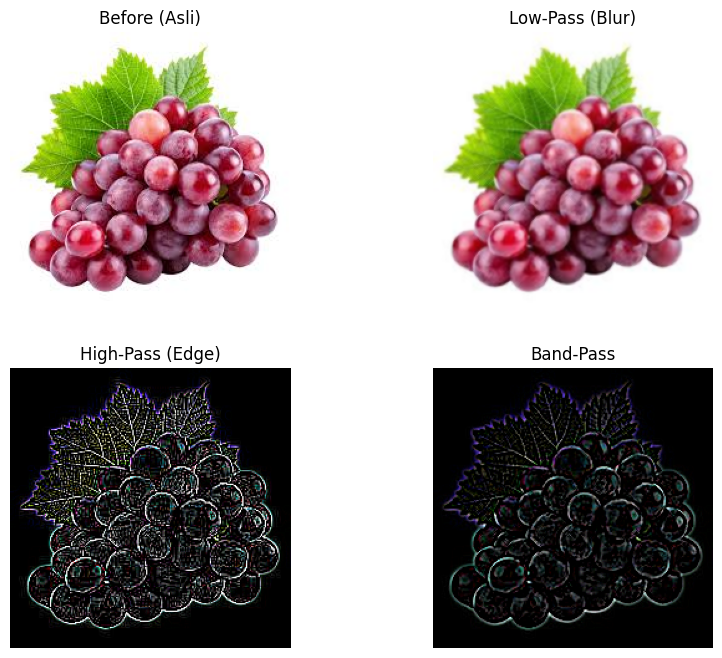

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
img = cv2.imread('/content/images.jpg')

# Convert BGR → RGB (biar warna normal di matplotlib)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ==============================
# LOW PASS (BLUR)
# ==============================
kernel = np.array([[1,1,1],[1,4,1],[1,1,1]], dtype=np.float32)
kernel /= np.sum(kernel)

low = cv2.filter2D(img_rgb, -1, kernel)

# ==============================
# HIGH PASS
# ==============================
high_kernel = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]], dtype=np.float32)

high = cv2.filter2D(img_rgb, -1, high_kernel)
high = cv2.normalize(high, None, 0, 255, cv2.NORM_MINMAX)

# ==============================
# BAND PASS
# ==============================
band = cv2.filter2D(low, -1, high_kernel)
band = cv2.normalize(band, None, 0, 255, cv2.NORM_MINMAX)

# ==============================
# TAMPILKAN
# ==============================
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.title("Before (Asli)")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(2,2,2)
plt.title("Low-Pass (Blur)")
plt.imshow(low)
plt.axis('off')

plt.subplot(2,2,3)
plt.title("High-Pass (Edge)")
plt.imshow(high)
plt.axis('off')

plt.subplot(2,2,4)
plt.title("Band-Pass")
plt.imshow(band)
plt.axis('off')

plt.show()